In [184]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
       RandomForestRegressor,
    GradientBoostingRegressor,
     StackingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
     classification_report
)

In [185]:
df=pd.read_csv("/content/Advanced_ML_Master_Dataset.csv")

In [186]:
df.head(5)

,Customer_ID,Age,Gender,Income,Credit_Score,Loan_Amount,Loan_Term_Months,Employment_Years,Debt_To_Income,Num_Credit_Cards,Savings,Transactions_Per_Month,Online_Purchases,Late_Payments,Region,Loan_Default,Future_Income
0,1,56,Male,74235,677,151370,12,26,0.73,0,657959,140,91,13,North,1,108344.0
1,2,69,Female,75342,711,148207,84,4,0.67,9,289463,38,79,6,North,0,104185.0
2,3,46,Female,193795,441,125138,24,19,0.46,3,807503,78,41,11,East,1,251793.0
3,4,32,Female,55572,557,77916,60,20,0.43,8,567056,91,40,9,North,0,86361.0
4,5,60,Male,37610,336,490341,72,2,0.76,3,243590,146,46,14,South,1,23007.0


In [187]:
df.shape

(10000, 17)

In [188]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months', 'Employment_Years', 'Debt_To_Income',
       'Num_Credit_Cards', 'Savings', 'Transactions_Per_Month',
       'Online_Purchases', 'Late_Payments', 'Region', 'Loan_Default',
       'Future_Income'],
      dtype='object')

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             10000 non-null  int64  
 1   Age                     10000 non-null  int64  
 2   Gender                  10000 non-null  object 
 3   Income                  10000 non-null  int64  
 4   Credit_Score            10000 non-null  int64  
 5   Loan_Amount             10000 non-null  int64  
 6   Loan_Term_Months        10000 non-null  int64  
 7   Employment_Years        10000 non-null  int64  
 8   Debt_To_Income          10000 non-null  float64
 9   Num_Credit_Cards        10000 non-null  int64  
 10  Savings                 10000 non-null  int64  
 11  Transactions_Per_Month  10000 non-null  int64  
 12  Online_Purchases        10000 non-null  int64  
 13  Late_Payments           10000 non-null  int64  
 14  Region                  10000 non-null 

In [190]:
df.describe()

,Customer_ID,Age,Income,Credit_Score,Loan_Amount,Loan_Term_Months,Employment_Years,Debt_To_Income,Num_Credit_Cards,Savings,Transactions_Per_Month,Online_Purchases,Late_Payments,Loan_Default,Future_Income
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,43.539400,109866.136200,603.493600,255878.98410,48.025200,19.479300,0.424487,5.533100,502963.91790,100.374200,49.452200,7.12850,0.400000,142739.734900
std,2886.89568,14.911636,51985.083111,173.869263,143223.98332,23.899868,11.584869,0.216334,3.423986,288486.51164,57.409569,29.018145,4.33085,0.489922,61754.726111
min,1.00000,18.000000,20016.000000,300.000000,5157.00000,12.000000,0.000000,0.050000,0.000000,205.00000,1.000000,0.000000,0.00000,0.000000,-19514.000000
25%,2500.75000,31.000000,64528.250000,452.000000,131040.75000,24.000000,9.000000,0.240000,3.000000,252771.00000,51.000000,24.000000,3.00000,0.000000,91879.000000
50%,5000.50000,43.000000,110572.500000,607.000000,258849.50000,48.000000,20.000000,0.430000,6.000000,502055.50000,101.000000,49.000000,7.00000,0.000000,143096.000000
75%,7500.25000,56.000000,154954.000000,755.000000,380875.75000,72.000000,29.000000,0.610000,9.000000,753792.75000,151.000000,75.000000,11.00000,1.000000,193308.250000
max,10000.00000,69.000000,199971.000000,899.000000,499915.00000,84.000000,39.000000,0.800000,11.000000,999967.00000,199.000000,99.000000,14.00000,1.000000,296602.000000


In [191]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term_Months,0
Employment_Years,0
Debt_To_Income,0
Num_Credit_Cards,0


In [192]:
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Region']=le.fit_transform(df['Region'])


In [193]:
df.head(5)

,Customer_ID,Age,Gender,Income,Credit_Score,Loan_Amount,Loan_Term_Months,Employment_Years,Debt_To_Income,Num_Credit_Cards,Savings,Transactions_Per_Month,Online_Purchases,Late_Payments,Region,Loan_Default,Future_Income
0,1,56,1,74235,677,151370,12,26,0.73,0,657959,140,91,13,1,1,108344.0
1,2,69,0,75342,711,148207,84,4,0.67,9,289463,38,79,6,1,0,104185.0
2,3,46,0,193795,441,125138,24,19,0.46,3,807503,78,41,11,0,1,251793.0
3,4,32,0,55572,557,77916,60,20,0.43,8,567056,91,40,9,1,0,86361.0
4,5,60,1,37610,336,490341,72,2,0.76,3,243590,146,46,14,2,1,23007.0


In [194]:
X = df.drop(
    [
        "Customer_ID",
        "Loan_Default",
        "Future_Income"
    ],
    axis=1
)

y=df["Loan_Default"]
print("\nFeature Shape:")
print(X.shape)


Feature Shape:
(10000, 14)


In [195]:
df.head(5)

,Customer_ID,Age,Gender,Income,Credit_Score,Loan_Amount,Loan_Term_Months,Employment_Years,Debt_To_Income,Num_Credit_Cards,Savings,Transactions_Per_Month,Online_Purchases,Late_Payments,Region,Loan_Default,Future_Income
0,1,56,1,74235,677,151370,12,26,0.73,0,657959,140,91,13,1,1,108344.0
1,2,69,0,75342,711,148207,84,4,0.67,9,289463,38,79,6,1,0,104185.0
2,3,46,0,193795,441,125138,24,19,0.46,3,807503,78,41,11,0,1,251793.0
3,4,32,0,55572,557,77916,60,20,0.43,8,567056,91,40,9,1,0,86361.0
4,5,60,1,37610,336,490341,72,2,0.76,3,243590,146,46,14,2,1,23007.0


In [196]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [197]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [198]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000,solver="liblinear"),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42)

}

In [199]:
results = []

for name, model in models.items():

    if name == "Logistic Regression":

        model.fit(
            X_train_scaled,
            y_train
        )

        predictions = model.predict(
            X_test_scaled
        )

        probabilities = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:,1]

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

In [200]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC_AUC"
    ]
)
print("\nMODEL COMPARISON")
results_df


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
0,Logistic Regression,0.9975,0.993850,1.000000,0.996915,0.999990
1,Random Forest,0.9555,0.966278,0.922030,0.943635,0.993088
2,Gradient Boosting,0.9700,0.969849,0.955446,0.962594,0.997578


In [201]:

best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("\nBEST MODEL")

print(best_model)



BEST MODEL
Model        Logistic Regression
Accuracy                  0.9975
Precision                0.99385
Recall                       1.0
F1 Score                0.996915
ROC_AUC                  0.99999
Name: 0, dtype: object


In [202]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        pred_rf
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1192
           1       0.97      0.92      0.94       808

    accuracy                           0.96      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.96      0.96      0.96      2000



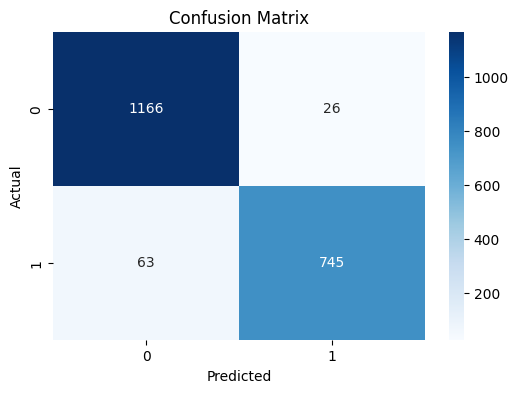

In [203]:

cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(
    figsize=(6,4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)
plt.show()


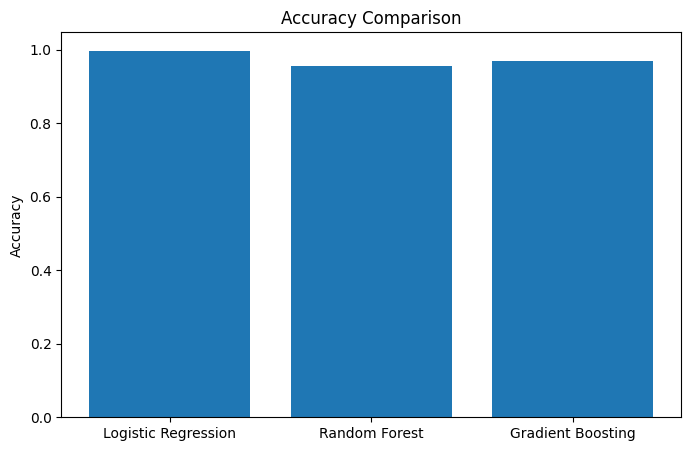

In [204]:

plt.figure(
    figsize=(8,5)
)

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title(
    "Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

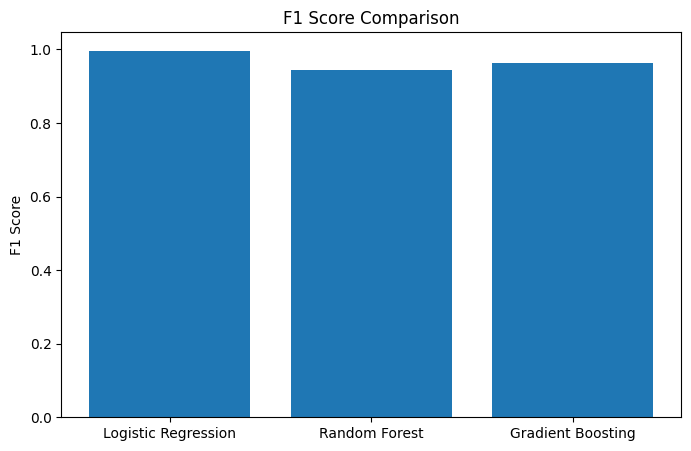

In [205]:

plt.figure(
    figsize=(8,5)
)

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title(
    "F1 Score Comparison"
)

plt.ylabel(
    "F1 Score"
)

plt.show()


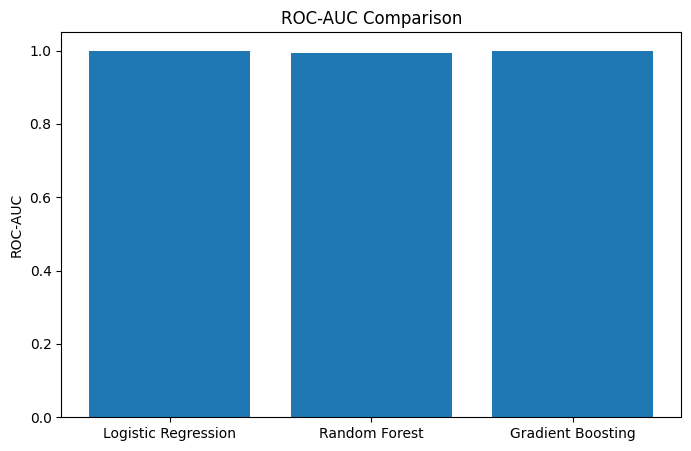

In [206]:
plt.figure(
    figsize=(8,5)
)

plt.bar(
    results_df["Model"],
    results_df["ROC_AUC"]
)

plt.title(
    "ROC-AUC Comparison"
)

plt.ylabel(
    "ROC-AUC"
)

plt.show()

   Depth  Train Accuracy  Test Accuracy
0    1.0        0.717125         0.6935
1    2.0        0.799000         0.7760
2    3.0        0.834125         0.8195
3    5.0        0.896125         0.8775
4   10.0        0.994750         0.9260
5   15.0        1.000000         0.9265
6   20.0        1.000000         0.9265
7    NaN        1.000000         0.9265


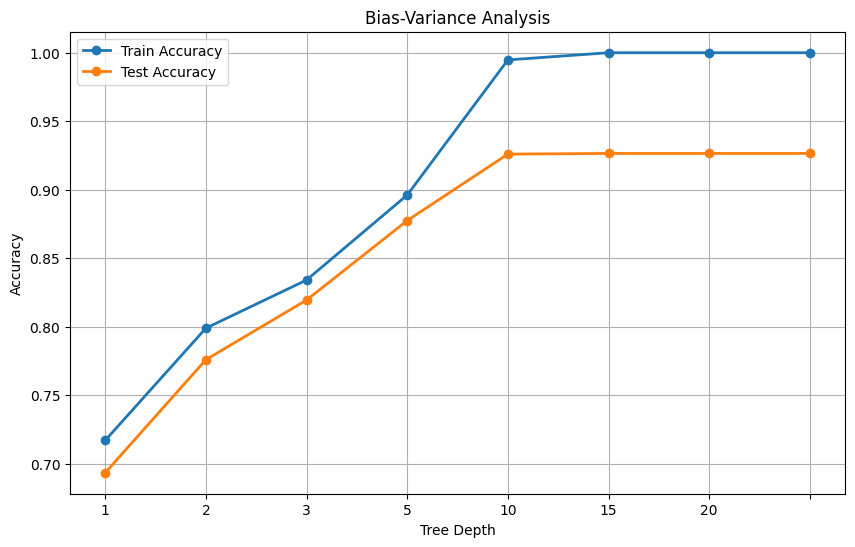

Best Depth: 15
Best Test Accuracy: 0.9265


In [207]:
# ==========================================
# Q2: Bias-Variance Analysis
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Different Tree Depths

depths = [1, 2, 3, 5, 10, 15, 20, None]

train_acc = []
test_acc = []

# Train Models

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    train_acc.append(
        train_accuracy
    )

    test_acc.append(
        test_accuracy
    )

# Results Table

results_df = pd.DataFrame({

    "Depth": depths,
    "Train Accuracy": train_acc,
    "Test Accuracy": test_acc

})

print(results_df)

# ==========================================
# Bias-Variance Plot
# ==========================================

plt.figure(figsize=(10,6))

plt.plot(
    range(len(depths)),
    train_acc,
    marker="o",
    linewidth=2,
    label="Train Accuracy"
)

plt.plot(
    range(len(depths)),
    test_acc,
    marker="o",
    linewidth=2,
    label="Test Accuracy"
)

plt.xticks(
    range(len(depths)),
    depths
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Analysis")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# Best Depth
# ==========================================

best_index = np.argmax(test_acc)

print(
    "Best Depth:",
    depths[best_index]
)

print(
    "Best Test Accuracy:",
    test_acc[best_index]
)

In [208]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

linear = LinearRegression()

ridge = Ridge(alpha=1)

lasso = Lasso(alpha=0.1)

linear.fit(
    X_train_scaled,
    y_train
)

ridge.fit(
    X_train_scaled,
    y_train
)

lasso.fit(
    X_train_scaled,
    y_train
)

Lasso(alpha=0.1)

In [209]:
linear_pred = linear.predict(
    X_test_scaled
)

ridge_pred = ridge.predict(
    X_test_scaled
)

lasso_pred = lasso.predict(
    X_test_scaled
)

In [210]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

results = []

models = {

    "Linear Regression":
    linear_pred,

    "Ridge":
    ridge_pred,

    "Lasso":
    lasso_pred

}

for name,pred in models.items():

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

print(results_df)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.256847  0.295588  0.637135
1              Ridge  0.256849  0.295587  0.637137
2              Lasso  0.328113  0.358046  0.467586


In [211]:
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print(best_model)

Model          Ridge
MAE         0.256849
RMSE        0.295587
R2 Score    0.637137
Name: 1, dtype: object


In [212]:
coef_df = pd.DataFrame({

    "Feature":
    X.columns,

    "Linear":
    linear.coef_,

    "Ridge":
    ridge.coef_,

    "Lasso":
    lasso.coef_

})

print(coef_df)

                   Feature    Linear     Ridge     Lasso
0                      Age  0.004386  0.004385  0.000000
1                   Gender -0.004268 -0.004266 -0.000000
2                   Income  0.000629  0.000629  0.000000
3             Credit_Score -0.247451 -0.247419 -0.143593
4              Loan_Amount  0.157328  0.157308  0.054396
5         Loan_Term_Months  0.003226  0.003226  0.000000
6         Employment_Years -0.001467 -0.001468 -0.000000
7           Debt_To_Income  0.115659  0.115644  0.016011
8         Num_Credit_Cards  0.000739  0.000740  0.000000
9                  Savings -0.001775 -0.001775 -0.000000
10  Transactions_Per_Month  0.001479  0.001479  0.000000
11        Online_Purchases -0.000194 -0.000193  0.000000
12           Late_Payments  0.240142  0.240112  0.138961
13                  Region  0.000666  0.000664 -0.000000


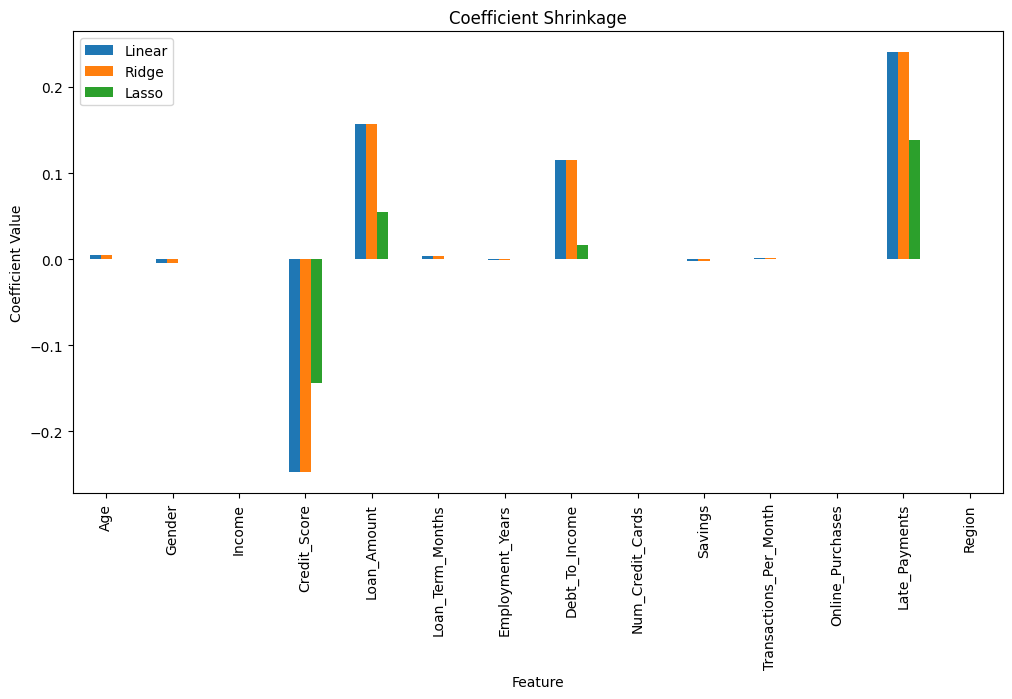

In [213]:
import matplotlib.pyplot as plt

coef_df.set_index(
    "Feature"
).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Coefficient Shrinkage"
)

plt.ylabel(
    "Coefficient Value"
)

plt.show()

In [214]:
print(
    "Features Removed:",
    np.sum(
        lasso.coef_ == 0
    )
)

Features Removed: 10


In [215]:
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print("\nBEST MODEL")

print(best_model)



BEST MODEL
Model          Ridge
MAE         0.256849
RMSE        0.295587
R2 Score    0.637137
Name: 1, dtype: object


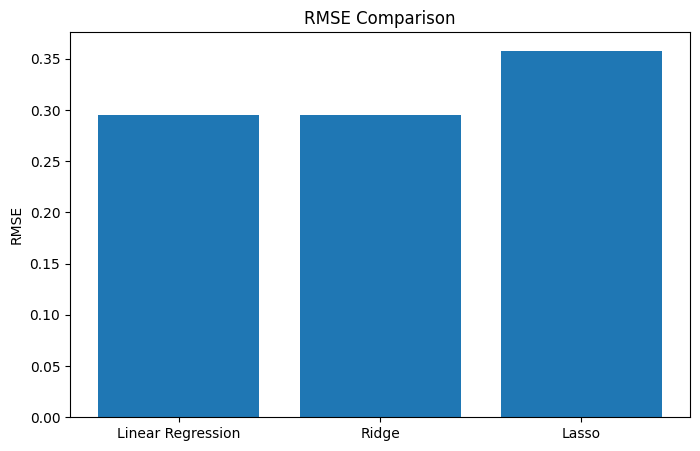

In [216]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title(
    "RMSE Comparison"
)

plt.ylabel(
    "RMSE"
)

plt.show()

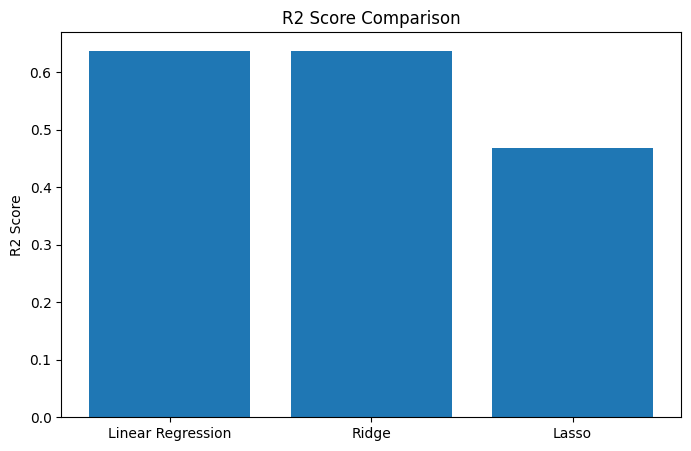

In [217]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title(
    "R2 Score Comparison"
)

plt.ylabel(
    "R2 Score"
)

plt.show()

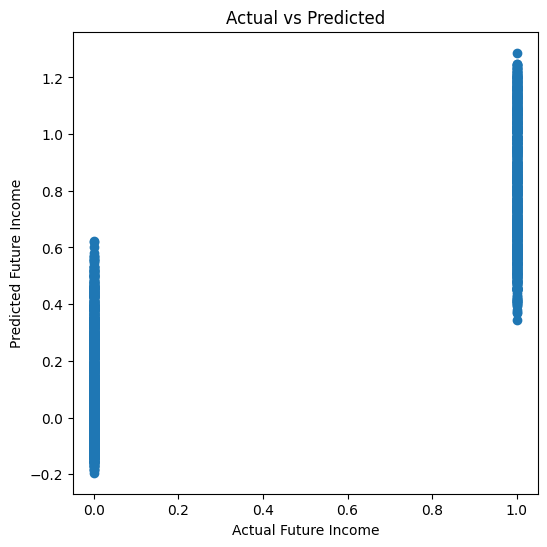

In [218]:
best_regressor = GradientBoostingRegressor(
    random_state=42
)

best_regressor.fit(
    X_train,
    y_train
)

pred = best_regressor.predict(
    X_test
)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred
)

plt.xlabel(
    "Actual Future Income"
)

plt.ylabel(
    "Predicted Future Income"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

In [219]:
df["Savings_Income_Ratio"] = (
    df["Savings"] /
    df["Income"]
)

df["Loan_Income_Ratio"] = (
    df["Loan_Amount"] /
    df["Income"]
)

print(
    df[
        [
            "Savings_Income_Ratio",
            "Loan_Income_Ratio"
        ]
    ].head()
)
X_class = df.drop(
    [
        "Customer_ID",
        "Loan_Default",
        "Future_Income"
    ],
    axis=1
)

y_class = df["Loan_Default"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42
)

# Logistic Regression

lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train_c,
    y_train_c
)

lr_pred = lr.predict(
    X_test_c
)

# Random Forest Classifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_c,
    y_train_c
)

rf_pred = rf.predict(
    X_test_c
)

print("\nCLASSIFICATION RESULTS")

print(
    "Logistic Accuracy:",
    accuracy_score(
        y_test_c,
        lr_pred
    )
)

print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test_c,
        rf_pred
    )
)

print(
    "Logistic F1:",
    f1_score(
        y_test_c,
        lr_pred
    )
)

print(
    "Random Forest F1:",
    f1_score(
        y_test_c,
        rf_pred
    )
)
X_reg = df.drop(
    [
        "Customer_ID",
        "Future_Income",
        "Loan_Default"
    ],
    axis=1
)

y_reg = df["Future_Income"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Linear Regression

lin = LinearRegression()

lin.fit(
    X_train_r,
    y_train_r
)

lin_pred = lin.predict(
    X_test_r
)

# Random Forest Regressor

rfr = RandomForestRegressor(
    random_state=42
)

rfr.fit(
    X_train_r,
    y_train_r
)

rfr_pred = rfr.predict(
    X_test_r
)

print("\nREGRESSION RESULTS")

print(
    "Linear RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test_r,
            lin_pred
        )
    )
)

print(
    "Random Forest RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test_r,
            rfr_pred
        )
    )
)

print(
    "Linear R2:",
    r2_score(
        y_test_r,
        lin_pred
    )
)

print(
    "Random Forest R2:",
    r2_score(
        y_test_r,
        rfr_pred
    )
)
importance_df = pd.DataFrame({

    "Feature":
    X_reg.columns,

    "Importance":
    rfr.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFEATURE IMPORTANCE")

print(
    importance_df
)
print("\nCONCLUSION")

print(
"""
New engineered features:
1. Savings_Income_Ratio
2. Loan_Income_Ratio

help capture financial stability and debt burden.

If Accuracy, F1 Score, or R2 Score increased
after adding these features, then Feature
Engineering improved model performance.
"""
)

   Savings_Income_Ratio  Loan_Income_Ratio
0              8.863191           2.039065
1              3.841987           1.967123
2              4.166790           0.645724
3             10.203988           1.402073
4              6.476735          13.037517


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



CLASSIFICATION RESULTS
Logistic Accuracy: 0.899
Random Forest Accuracy: 0.9585
Logistic F1: 0.8740648379052369
Random Forest F1: 0.9477658904971681

REGRESSION RESULTS
Linear RMSE: 14618.370893322111
Random Forest RMSE: 15136.079986679037
Linear R2: 0.9419450809607615
Random Forest R2: 0.9377602414847866

FEATURE IMPORTANCE
                   Feature  Importance
2                   Income    0.895447
6         Employment_Years    0.054072
3             Credit_Score    0.005335
10  Transactions_Per_Month    0.005112
11        Online_Purchases    0.004958
7           Debt_To_Income    0.004815
0                      Age    0.004564
12           Late_Payments    0.004523
9                  Savings    0.003439
14    Savings_Income_Ratio    0.003435
15       Loan_Income_Ratio    0.003359
4              Loan_Amount    0.003336
8         Num_Credit_Cards    0.003083
5         Loan_Term_Months    0.002303
13                  Region    0.001577
1                   Gender    0.000641

CONCLUSIO

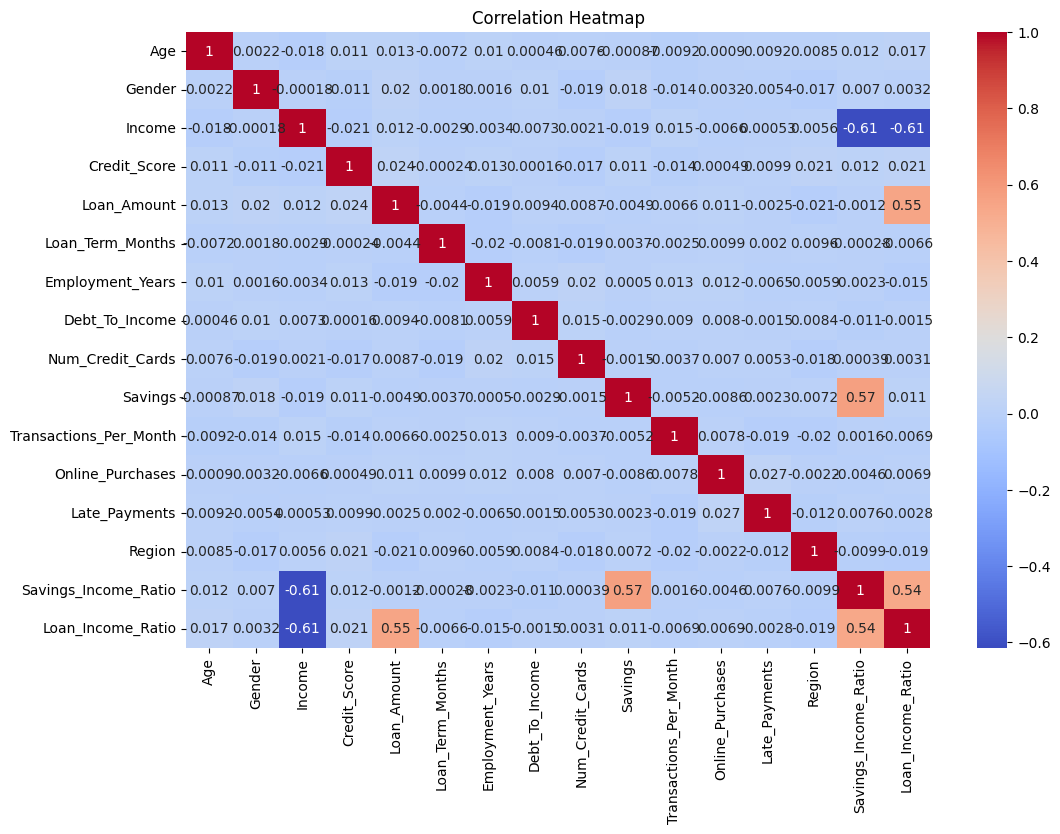

In [220]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove non-useful columns
feature_df = df.drop(
    [
        "Customer_ID",
        "Loan_Default",
        "Future_Income"
    ],
    axis=1
)

plt.figure(figsize=(12,8))

sns.heatmap(
    feature_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [221]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Classification Target
X = df.drop(
    [
        "Customer_ID",
        "Loan_Default",
        "Future_Income"
    ],
    axis=1
)

y = df["Loan_Default"]

selector = SelectKBest(
    score_func=f_classif,
    k=8
)

X_selected = selector.fit_transform(
    X,
    y
)

selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:\n")

print(selected_features)

Selected Features:

Index(['Credit_Score', 'Loan_Amount', 'Employment_Years', 'Debt_To_Income',
       'Num_Credit_Cards', 'Online_Purchases', 'Late_Payments',
       'Loan_Income_Ratio'],
      dtype='object')


                   Feature  Importance
3             Credit_Score    0.302465
12           Late_Payments    0.276894
4              Loan_Amount    0.103986
7           Debt_To_Income    0.087989
15       Loan_Income_Ratio    0.058448
2                   Income    0.024589
14    Savings_Income_Ratio    0.021876
9                  Savings    0.020268
10  Transactions_Per_Month    0.019443
11        Online_Purchases    0.018346
0                      Age    0.018070
6         Employment_Years    0.016793
8         Num_Credit_Cards    0.012111
5         Loan_Term_Months    0.009435
13                  Region    0.006356
1                   Gender    0.002932


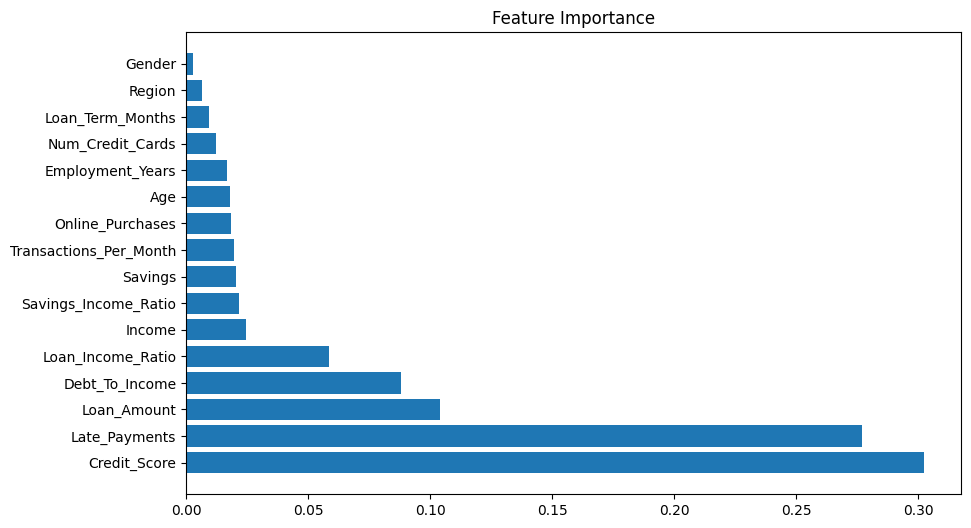

In [222]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X,
    y
)

importance_df = pd.DataFrame({

    "Feature":
    X.columns,

    "Importance":
    rf.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title(
    "Feature Importance"
)

plt.show()

In [223]:
X_reduced = X[
    selected_features
]

print(
    "Original Features:",
    X.shape[1]
)

print(
    "Reduced Features:",
    X_reduced.shape[1]
)

Original Features: 16
Reduced Features: 8


In [224]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf_before = RandomForestClassifier(
    random_state=42
)

rf_before.fit(
    X_train,
    y_train
)

pred_before = rf_before.predict(
    X_test
)

acc_before = accuracy_score(
    y_test,
    pred_before
)

print(
    "Accuracy Before:",
    acc_before
)

Accuracy Before: 0.9585


In [225]:
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_reduced,
    y,
    test_size=0.20,
    random_state=42
)

rf_after = RandomForestClassifier(
    random_state=42
)

rf_after.fit(
    X_train_fs,
    y_train_fs
)

pred_after = rf_after.predict(
    X_test_fs
)

acc_after = accuracy_score(
    y_test_fs,
    pred_after
)

print(
    "Accuracy After:",
    acc_after
)

Accuracy After: 0.959


In [226]:
comparison = pd.DataFrame({

    "Model":
    ["Random Forest"],

    "Before Feature Selection":
    [acc_before],

    "After Feature Selection":
    [acc_after]

})

print(comparison)

           Model  Before Feature Selection  After Feature Selection
0  Random Forest                    0.9585                    0.959


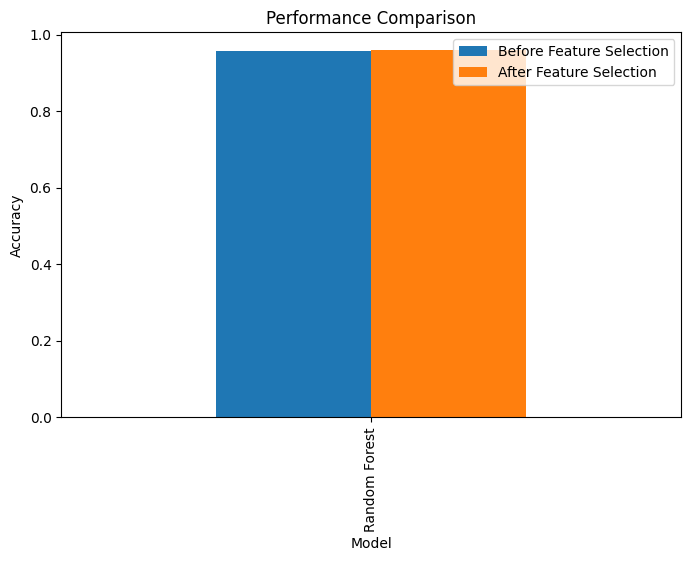

In [227]:
comparison.set_index(
    "Model"
).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Performance Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [228]:
print("Trained Bagging, Random Forest, AdaBoost and Gradient Boosting classifiers.")
print("Predicted Loan_Default using ensemble learning models.")
print("Compared Accuracy, Precision, Recall and F1 Score.")
print(
    "Ensemble methods combine predictions from multiple models, "
    "reduce overfitting, reduce variance, improve generalization "
    "and usually achieve higher accuracy than a single model."
)

Trained Bagging, Random Forest, AdaBoost and Gradient Boosting classifiers.
Predicted Loan_Default using ensemble learning models.
Compared Accuracy, Precision, Recall and F1 Score.
Ensemble methods combine predictions from multiple models, reduce overfitting, reduce variance, improve generalization and usually achieve higher accuracy than a single model.


In [229]:
base_learners = [

    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),

    (
        "rf",
        RandomForestClassifier(
            random_state=42
        )
    ),

    (
        "gb",
        GradientBoostingClassifier(
            random_state=42
        )
    )

]

In [230]:
stack_model = StackingClassifier(

    estimators=base_learners,

    final_estimator=
    LogisticRegression(
        max_iter=5000
    )

)

In [231]:
print(results)

[['Linear Regression', 0.2568472083134986, np.float64(0.2955876496446626), 0.6371351143661713], ['Ridge', 0.25684947663649127, np.float64(0.29558702538600184), 0.6371366470506974], ['Lasso', 0.32811345029440936, np.float64(0.35804592119189477), 0.46758554687125187]]


In [232]:
for row in results:
    print(len(row), row)

4 ['Linear Regression', 0.2568472083134986, np.float64(0.2955876496446626), 0.6371351143661713]
4 ['Ridge', 0.25684947663649127, np.float64(0.29558702538600184), 0.6371366470506974]
4 ['Lasso', 0.32811345029440936, np.float64(0.35804592119189477), 0.46758554687125187]


In [233]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall"
    ]
)

In [234]:
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print(best_model)

Model           Lasso
Accuracy     0.328113
Precision    0.358046
Recall       0.467586
Name: 2, dtype: object


In [235]:
import time
start_time = time.time()

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

untuned_pred = rf.predict(
    X_test
)

untuned_time = time.time() - start_time

untuned_accuracy = accuracy_score(
    y_test,
    untuned_pred
)

untuned_precision = precision_score(
    y_test,
    untuned_pred
)

untuned_recall = recall_score(
    y_test,
    untuned_pred
)

untuned_f1 = f1_score(
    y_test,
    untuned_pred
)


In [179]:
param_grid = {

    "n_estimators":
    [100, 200],

    "max_depth":
    [5, 10, None],

    "min_samples_split":
    [2, 5],

    "min_samples_leaf":
    [1, 2]

}

grid_search = GridSearchCV(

    estimator=
    RandomForestClassifier(
        random_state=42
    ),

    param_grid=
    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)
start_time = time.time()

grid_search.fit(
    X_train,
    y_train
)

tuned_time = time.time() - start_time

In [180]:
best_rf = grid_search.best_estimator_

tuned_pred = best_rf.predict(
    X_test
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred
)

In [181]:
print("\nBEST HYPERPARAMETERS\n")

print(
    grid_search.best_params_
)


BEST HYPERPARAMETERS

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [182]:
comparison = pd.DataFrame({

    "Metric":
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Untuned":
    [
        untuned_accuracy,
        untuned_precision,
        untuned_recall,
        untuned_f1
    ],

    "Tuned":
    [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]

})

print("\nMODEL COMPARISON\n")

print(comparison)


MODEL COMPARISON

      Metric   Untuned     Tuned
0   Accuracy  0.958500  0.958000
1  Precision  0.964149  0.966495
2     Recall  0.931931  0.928218
3   F1 Score  0.947766  0.946970


In [183]:
print("\nUNTUNED TRAINING TIME")

print(
    round(
        untuned_time,
        2
    ),
    "seconds"
)

print("\nTUNED TRAINING TIME")

print(
    round(
        tuned_time,
        2
    ),
    "seconds"
)



UNTUNED TRAINING TIME
3.51 seconds

TUNED TRAINING TIME
159.15 seconds


In [236]:
# Best model from previous questions

from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

best_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


                   Feature  Importance
3             Credit_Score    0.328844
12           Late_Payments    0.289502
4              Loan_Amount    0.111835
7           Debt_To_Income    0.086101
15       Loan_Income_Ratio    0.052259
2                   Income    0.020037
14    Savings_Income_Ratio    0.017098
9                  Savings    0.015924
11        Online_Purchases    0.015061
10  Transactions_Per_Month    0.014986
0                      Age    0.013312
6         Employment_Years    0.013068
8         Num_Credit_Cards    0.009144
5         Loan_Term_Months    0.006714
13                  Region    0.004317
1                   Gender    0.001799


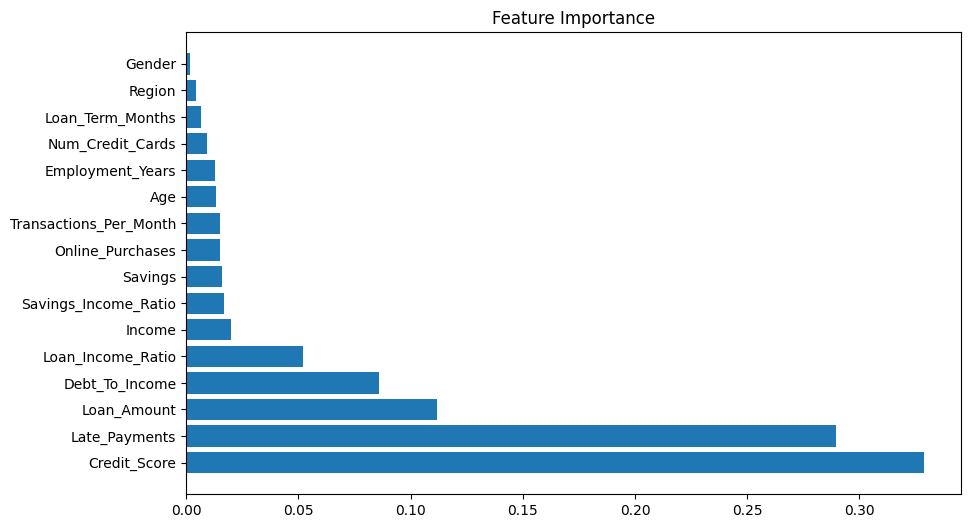

In [237]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [238]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(

    best_model,

    X_test,

    y_test,

    n_repeats=10,

    random_state=42

)

perm_df = pd.DataFrame({

    "Feature": X.columns,

    "Permutation Importance":
    perm.importances_mean

})

perm_df = perm_df.sort_values(
    by="Permutation Importance",
    ascending=False
)

print(perm_df)

                   Feature  Permutation Importance
12           Late_Payments                 0.24835
3             Credit_Score                 0.23160
4              Loan_Amount                 0.10420
7           Debt_To_Income                 0.08920
15       Loan_Income_Ratio                 0.02310
2                   Income                 0.00165
5         Loan_Term_Months                 0.00100
0                      Age                 0.00100
11        Online_Purchases                 0.00090
13                  Region                 0.00050
10  Transactions_Per_Month                 0.00020
9                  Savings                -0.00010
1                   Gender                -0.00025
8         Num_Credit_Cards                -0.00040
14    Savings_Income_Ratio                -0.00050
6         Employment_Years                -0.00085


In [239]:
pip install shap

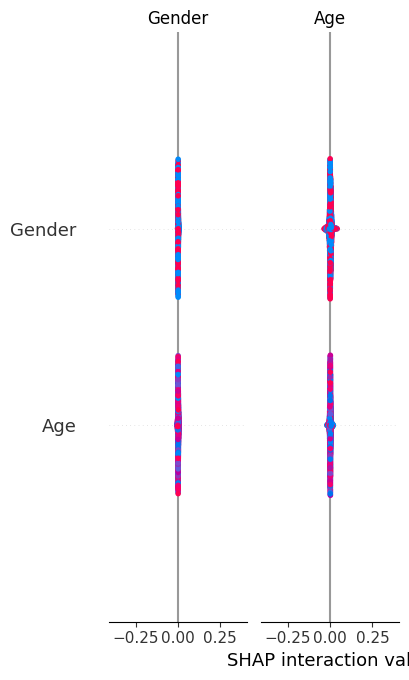

In [240]:
import shap

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_test
)

shap.summary_plot(
    shap_values,
    X_test
)